# Aula 1 — Análise descritiva e diagnóstica: o caso da limonada

**Análise Preditiva** · material de aula (fora do livro) · dataset: [`ml-zero/dados/limonada/`](https://github.com/GHDaru/machinelearning/tree/main/ml-zero/dados/limonada)

365 dias de uma barraca de limonada: tempo que fez, panfletos distribuídos, preço praticado e copos vendidos. O dado é sintético e limpo de propósito — as armadilhas aparecem sem ruído para escondê-las.

**Roteiro desta aula:**

1. **O dado** — tipos e papéis de cada coluna.
2. **Análise descritiva** de cada campo quantitativo — histograma com boxplot superior, outliers, assimetria, curtose e os cuidados especiais de cada um.
3. **Análise par a par** — todos os cruzamentos num único comando, e depois os pares que importam, um a um.
4. **Análise diagnóstica** — correlações entre as variáveis, e a armadilha que mora nelas.
5. **O calendário** — vendas por dia da semana e ao longo do ano.

Ao final: **prova de 10 questões no Google Forms**, só sobre esta parte.

> **Aula que vem:** o modelo — regressão linear aplicada **item a item** contra `vendas`, avaliação dos ajustes, modelo múltiplo, Ridge/Lasso e transformação de variáveis.


In [1]:
# --- roda igual na sua máquina e no Colab ------------------------------
# No Colab não há repositório: o CSV é baixado direto do GitHub.
import pathlib, urllib.request

RAW = "https://raw.githubusercontent.com/GHDaru/machinelearning/main/"
CSV = "ml-zero/dados/limonada/limonada.csv"

raiz = pathlib.Path.cwd()
for _ in range(5):
    if (raiz / "ml-zero").is_dir():
        break
    raiz = raiz.parent
else:
    raiz = pathlib.Path.cwd()

caminho = raiz / CSV
if not caminho.exists():
    caminho.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(RAW + CSV, caminho)
print("dados em:", caminho)

dados em: /home/user/machinelearning/ml-zero/dados/limonada/limonada.csv


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*vert.*")

# Paleta da aula: um matiz para o dado, laranja só quando há duas séries a
# contrastar, cinza para o que é contexto. Cor segue papel, não enfeite.
AZUL, LARANJA, CINZA = "#4477AA", "#EE7733", "#BBBBBB"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 10,
})

## 1. O dado

Sete colunas, 365 linhas, nenhum valor faltante. Antes de qualquer gráfico: **que tipo é cada coluna?**

In [3]:
df = pd.read_csv(caminho, parse_dates=["data"])
print(df.shape)
df.head()

(365, 7)


,data,dia_semana,temperatura,precipitacao,panfletos,preco,vendas
0,2017-01-01,Sunday,27.0,2.00,15,0.3,10
1,2017-01-02,Monday,28.9,1.33,15,0.3,13
2,2017-01-03,Tuesday,34.5,1.33,27,0.3,15
3,2017-01-04,Wednesday,44.1,1.05,28,0.3,17
4,2017-01-05,Thursday,42.4,1.00,33,0.3,18


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          365 non-null    datetime64[us]
 1   dia_semana    365 non-null    str           
 2   temperatura   365 non-null    float64       
 3   precipitacao  365 non-null    float64       
 4   panfletos     365 non-null    int64         
 5   preco         365 non-null    float64       
 6   vendas        365 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(1)
memory usage: 20.1 KB


Separando por papel:

| Coluna | Tipo | Papel |
|---|---|---|
| `data` | temporal | índice — não entra no modelo como número |
| `dia_semana` | categórica | medida na seção 5 (o calendário) |
| `temperatura`, `precipitacao`, `panfletos` | quantitativas contínuas | candidatas a preditoras |
| `preco` | quantitativa **com só dois valores** | guarde isso — vai importar já na descritiva |
| `vendas` | quantitativa (contagem) | **alvo** (`y`) |


## 2. Análise descritiva, campo a campo

O instrumento da aula: **histograma com o boxplot em cima**, compartilhando o eixo x. O boxplot resume (mediana, quartis, cercas); o histograma mostra a forma que o resumo esconde. Junto, imprimimos assimetria (*skewness*), curtose (excesso, referência normal = 0) e a contagem de outliers pela regra do IQR (cerca = quartil ± 1,5×IQR).

In [5]:
QUANTS = ["temperatura", "precipitacao", "panfletos", "preco", "vendas"]

def resumo(s: pd.Series) -> dict:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = s[(s < lo) | (s > hi)]
    return {"n": len(s), "média": s.mean(), "dp": s.std(), "mín": s.min(),
            "Q1": q1, "mediana": s.median(), "Q3": q3, "máx": s.max(),
            "assimetria": s.skew(), "curtose": s.kurt(),
            "cerca inf": lo, "cerca sup": hi, "outliers (IQR)": len(outliers)}

def descritiva(coluna: str, bins=25):
    s = df[coluna]
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, sharex=True, figsize=(7, 3.6),
        gridspec_kw={"height_ratios": [1, 4], "hspace": 0.05})
    ax_box.boxplot(s, vert=False, widths=0.55, patch_artist=True,
                   boxprops=dict(facecolor=AZUL, alpha=0.45, edgecolor=AZUL),
                   medianprops=dict(color=LARANJA, linewidth=2),
                   flierprops=dict(marker="o", markersize=4,
                                   markerfacecolor=LARANJA, markeredgecolor="none"))
    ax_box.set(yticks=[], title=coluna)
    ax_box.grid(False)
    ax_hist.hist(s, bins=bins, color=AZUL, edgecolor="white", linewidth=0.6)
    ax_hist.set_ylabel("dias")
    ax_hist.grid(axis="x", visible=False)
    plt.show()
    linha = pd.Series(resumo(s)).to_frame(coluna).T
    return linha.round(3)

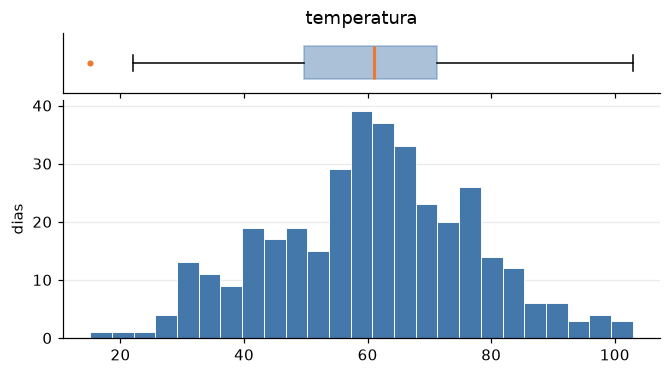

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
temperatura,365.0,60.731,16.196,15.1,49.7,61.1,71.3,102.9,-0.005,-0.22,17.3,103.7,1.0


In [6]:
descritiva("temperatura")

**Temperatura** — distribuição praticamente **simétrica** (assimetria ≈ 0) e um pouco mais "achatada" que a normal (curtose levemente negativa). Um único ponto abaixo da cerca inferior: o dia mais frio do ano. É outlier *estatístico*, não erro de medição — **fica**.

⚠️ **Cuidado especial:** olhe a escala. Mínimo ~15, máximo ~103, média ~61 — isso é **Fahrenheit**, não Celsius. Ler como °C produziria conclusões absurdas ("vendem limonada a 15 °C mais do que a 27 °C?"). Unidade é a primeira coisa que a descritiva confere.

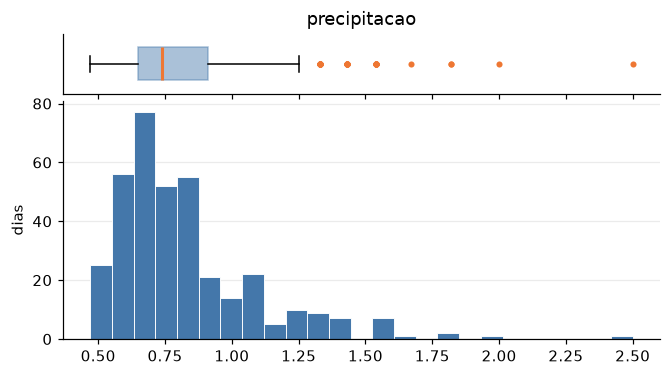

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
precipitacao,365.0,0.827,0.273,0.47,0.65,0.74,0.91,2.5,1.855,5.244,0.26,1.3,28.0


In [7]:
descritiva("precipitacao")

**Precipitação** — aqui a forma muda: **assimetria à direita forte (~1,9)** e **curtose alta (~5)**: cauda longa e pesada. A maioria dos dias tem chuva baixa; alguns poucos têm chuva forte — e a regra do IQR marca ~28 pontos acima da cerca superior.

**Tratamento:** *nenhuma exclusão*. Chuva forte é fenômeno real e é justamente o que derruba venda — apagar esses dias seria apagar a informação. O que a assimetria sugere é outra coisa: esta é a **candidata natural a transformação (log)**, que a próxima aula testa. Anote e siga.

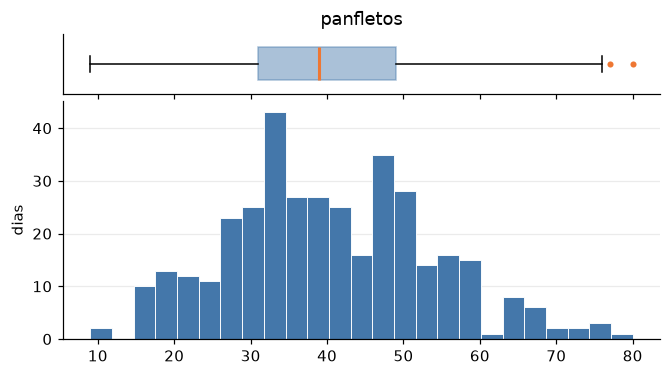

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
panfletos,365.0,40.285,13.179,9.0,31.0,39.0,49.0,80.0,0.306,-0.147,4.0,76.0,2.0


In [8]:
descritiva("panfletos")

**Panfletos** — quase simétrica (assimetria ~0,3), curtose próxima de zero, dois pontos acima da cerca (77 e 80 panfletos). Valores plausíveis para dias de pico — **ficam**. Nenhum tratamento.

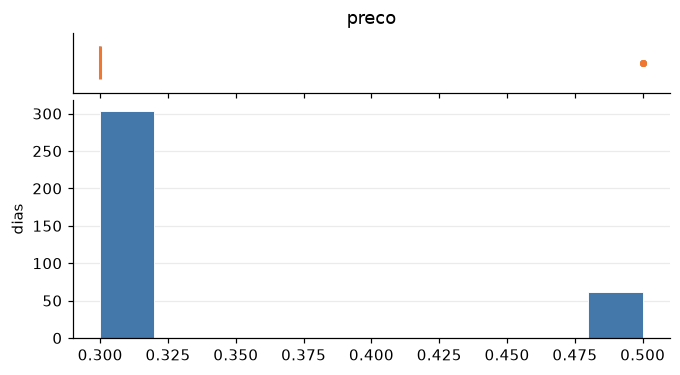

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
preco,365.0,0.334,0.075,0.3,0.3,0.3,0.3,0.5,1.766,1.123,0.3,0.3,62.0


In [9]:
descritiva("preco", bins=10)

**Preço** — e aqui está a **pegadinha da aula**. A regra do IQR marcou **62 outliers**… porque Q1 = Q3 = 0,30: o IQR é **zero**, a cerca colapsa num ponto, e *todo* dia de preço 0,50 vira "outlier".

O diagnóstico correto: `preco` só assume **dois valores** (0,30 e 0,50). Histograma, boxplot, assimetria e curtose pressupõem variável **contínua** — aplicados a uma variável binária, produzem números sem significado. **Tratamento:** tratar `preco` como variável **binária/indicadora**, não como contínua. Remover os "62 outliers" seria deletar julho e agosto do dataset.

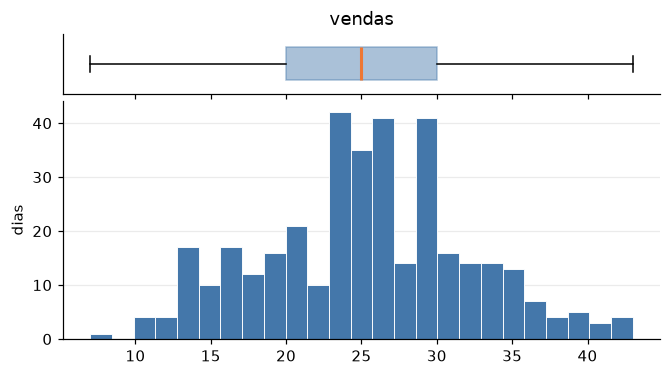

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
vendas,365.0,25.323,6.894,7.0,20.0,25.0,30.0,43.0,0.024,-0.25,5.0,45.0,0.0


In [10]:
descritiva("vendas")

**Vendas (o alvo)** — simétrica, curtose próxima de zero, **zero outliers**. Alvo bem-comportado; nenhuma transformação necessária nele.

### Síntese da descritiva

In [11]:
pd.DataFrame({c: resumo(df[c]) for c in QUANTS}).T.round(3)

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
temperatura,365.0,60.731,16.196,15.10,49.70,61.10,71.30,102.9,-0.005,-0.220,17.30,103.7,1.0
precipitacao,365.0,0.827,0.273,0.47,0.65,0.74,0.91,2.5,1.855,5.244,0.26,1.3,28.0
panfletos,365.0,40.285,13.179,9.00,31.00,39.00,49.00,80.0,0.306,-0.147,4.00,76.0,2.0
preco,365.0,0.334,0.075,0.30,0.30,0.30,0.30,0.5,1.766,1.123,0.30,0.3,62.0
vendas,365.0,25.323,6.894,7.00,20.00,25.00,30.00,43.0,0.024,-0.250,5.00,45.0,0.0


**Cuidados especiais que esta tabela deixa (leve para qualquer dataset):**

1. **Unidade antes de interpretação** — a temperatura está em °F.
2. **Outlier não é sinônimo de erro.** Os de precipitação e panfletos são fenômeno real; excluir seria viés. A decisão é sempre *investigar → decidir*, nunca *deletar por regra*.
3. **A regra do IQR pressupõe variável contínua.** Em variável binária ou quase-discreta ela colapsa (caso do `preco`).
4. **Assimetria forte + cauda pesada** não pede exclusão: pede considerar **transformação** — e medir se ajuda.
5. Tratamento adotado: **nenhuma linha removida**; `preco` lido como binária; log em `precipitacao` a testar na próxima aula.

## 3. Análise par a par

A descritiva olhou cada campo sozinho. Antes de qualquer número de correlação, **olhe os cruzamentos**. Primeiro o panorama: um único comando desenha todos os pares (dispersões fora da diagonal, histogramas na diagonal).

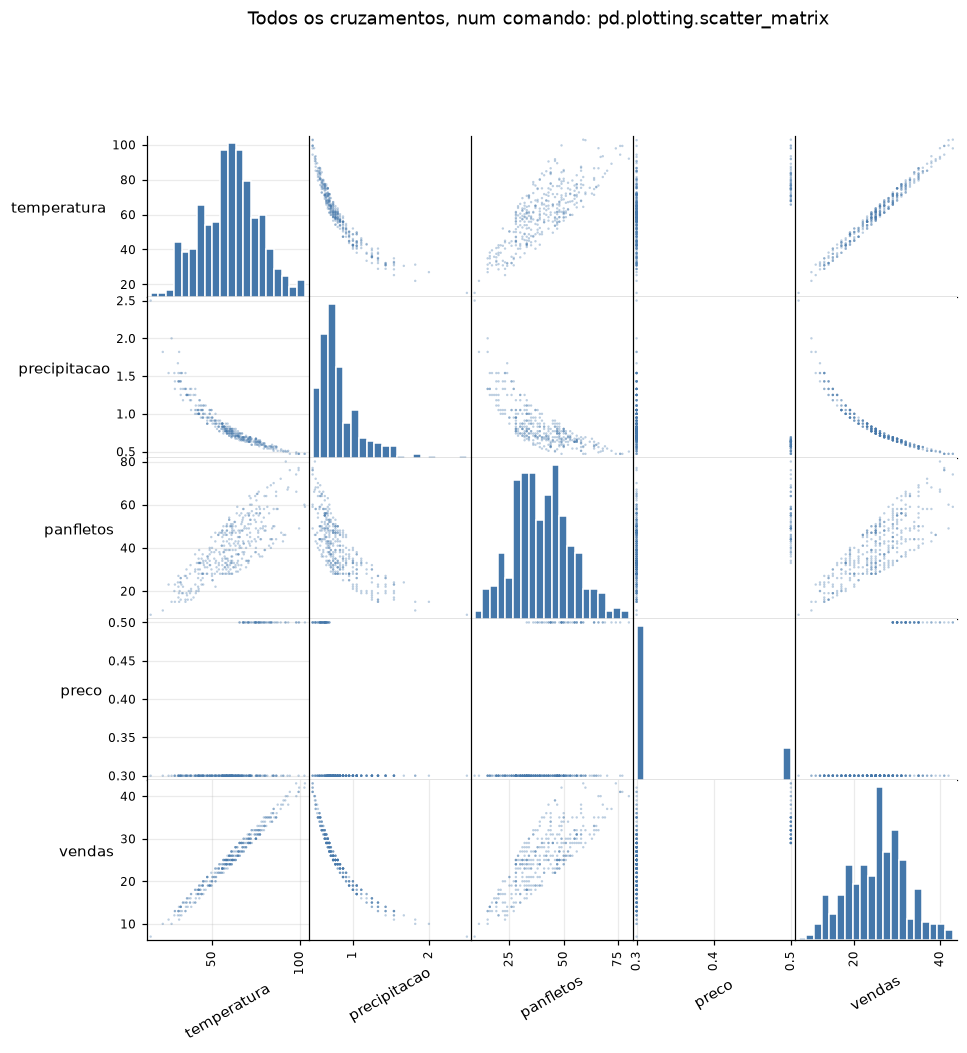

In [12]:
eixos = pd.plotting.scatter_matrix(
    df[QUANTS], figsize=(9.5, 9.5), diagonal="hist", alpha=0.35,
    color=AZUL, hist_kwds=dict(color=AZUL, edgecolor="white", bins=20),
    s=10)
for linha_ax in eixos:
    for ax in linha_ax:
        ax.xaxis.label.set_rotation(30)
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha("right")
plt.suptitle("Todos os cruzamentos, num comando: pd.plotting.scatter_matrix", y=1.0)
plt.show()

Como se lê uma matriz destas, em três passadas:

1. **Última linha/coluna (o alvo):** `vendas` sobe reta com `temperatura`, desce com `precipitacao`, sobe difusa com `panfletos`.
2. **Faixas horizontais denunciam variável discreta:** todo par com `preco` vira duas linhas de pontos — a matriz *mostra* o que a descritiva diagnosticou (dois valores, tratar como binária).
3. **Entre preditoras:** `temperatura` × `panfletos` tem inclinação clara — colinearidade, que vai bagunçar a leitura dos coeficientes na próxima aula.

O panorama aponta; agora **cada par que importa, em close** — dispersão quando os dois lados são contínuos, boxplot por grupo quando um lado é binário.

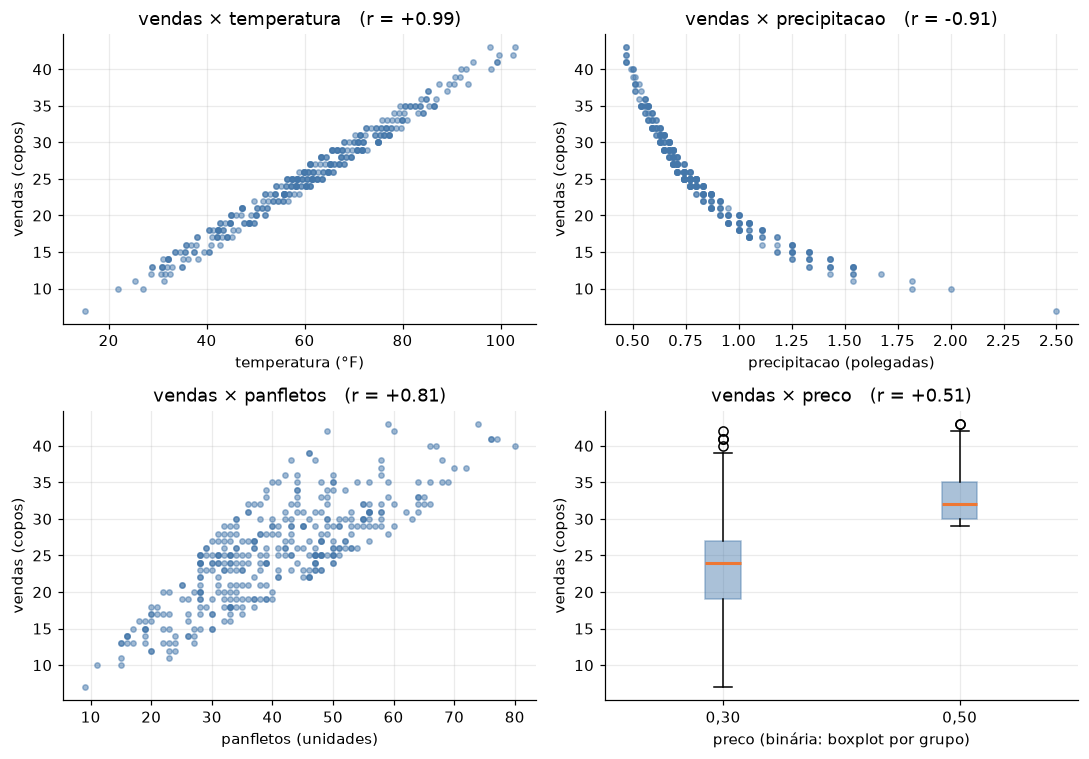

In [13]:
fig, eixos = plt.subplots(2, 2, figsize=(10, 7))
pares = [("temperatura", "°F"), ("precipitacao", "polegadas"), ("panfletos", "unidades")]
for ax, (col, unid) in zip(eixos.flat, pares):
    ax.scatter(df[col], df.vendas, s=12, color=AZUL, alpha=0.5)
    r = df[col].corr(df.vendas)
    ax.set(xlabel=f"{col} ({unid})", ylabel="vendas (copos)",
           title=f"vendas × {col}   (r = {r:+.2f})")

ax = eixos.flat[3]
grupos = [df.loc[df.preco == p, "vendas"] for p in (0.3, 0.5)]
ax.boxplot(grupos, tick_labels=["0,30", "0,50"], patch_artist=True,
           boxprops=dict(facecolor=AZUL, alpha=0.45, edgecolor=AZUL),
           medianprops=dict(color=LARANJA, linewidth=2))
r = df.preco.corr(df.vendas)
ax.set(xlabel="preco (binária: boxplot por grupo)", ylabel="vendas (copos)",
       title=f"vendas × preco   (r = {r:+.2f})")
plt.tight_layout(); plt.show()

Leitura par a par:

- **temperatura** — a relação mais forte do conjunto, e visivelmente **linear**: bom presságio para um modelo linear.
- **precipitacao** — negativa e com a cauda da chuva forte puxando vendas para baixo; repare que a nuvem **encurva** — não é bem uma reta.
- **panfletos** — positiva, porém difusa. Quanto disso é panfleto e quanto é o calor do dia que fez alguém panfletar mais? A dispersão não responde.
- **preco** — o grupo de 0,50 vende **mais** em mediana. Guarde o incômodo: a seção seguinte mostra por quê.

### A fórmula por trás do r

O número nos títulos é a **correlação de Pearson**:

$$r_{xy} = \frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_i (x_i-\bar{x})^2}\,\sqrt{\sum_i (y_i-\bar{y})^2}} = \frac{\text{cov}(x,y)}{s_x\,s_y}$$

A covariância dividida pelo produto dos desvios-padrão: sem unidade, presa a [−1, +1]. Ela mede **associação linear** — uma relação em U forte pode dar r ≈ 0 — e não diz nada sobre causa.

## 4. Análise diagnóstica: as correlações

O olho viu as formas; agora o número resume **como os campos se movem juntos** — e é onde nasce a primeira conclusão errada.

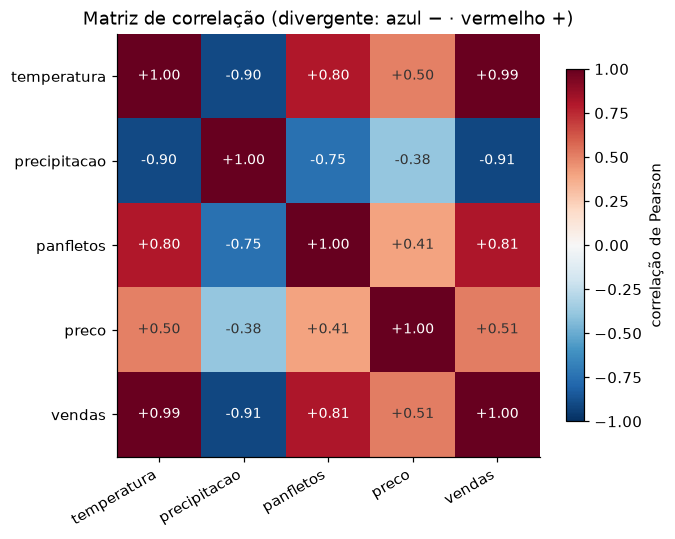

In [14]:
corr = df[QUANTS].corr()

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(QUANTS)), QUANTS, rotation=30, ha="right")
ax.set_yticks(range(len(QUANTS)), QUANTS)
for i in range(len(QUANTS)):
    for j in range(len(QUANTS)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "#333333", fontsize=9)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlação de Pearson")
ax.set_title("Matriz de correlação (divergente: azul − · vermelho +)")
plt.show()

Três leituras, em ordem de perigo:

1. **Com o alvo:** `temperatura` +0,99 (quase determinística!), `precipitacao` −0,91, `panfletos` +0,81… e **`preco` +0,51**. Lido ingenuamente: *"suba o preço, que a venda sobe"*. Segure essa — é a armadilha central.
2. **Entre preditoras:** `temperatura` × `panfletos` ≈ +0,80 — distribuía-se mais panfleto em dia quente. Isso é **colinearidade**, e vai contaminar a *leitura* dos coeficientes (não a previsão).
3. `temperatura` × `precipitacao` fortemente negativa — as preditoras carregam, todas, o mesmo fator por trás: **a estação**.

In [15]:
df.assign(mes=df.data.dt.month).groupby("preco").agg(
    dias=("vendas", "size"), temperatura_media=("temperatura", "mean"),
    vendas_medias=("vendas", "mean"),
    meses=("mes", lambda m: sorted(m.unique()))).round(1)

,dias,temperatura_media,vendas_medias,meses
preco,,,,
0.3,303,57.0,23.7,"[1, 2, 3, 4, 5, 6, 9, 10, 11, 12]"
0.5,62,78.8,33.1,"[7, 8]"


O preço de 0,50 **só existe em julho e agosto** — os dois meses mais quentes. `preco` não é alavanca aqui: é um **termômetro disfarçado**. A correlação +0,51 mede o verão, não a disposição do freguês a pagar.

> Diagnóstico ≠ recomendação. A correlação diz *o que anda junto*; ela não diz *o que causa o quê* — e nenhum mês do ano tem dois preços, então **não há recorte destes dados** que separe preço de estação. (A história completa está no [capítulo II.2 do livro](https://machinelearning.ghdaru.com.br/ii-2-modelos-lineares.html).)

## 5. O calendário: dia da semana e o ano inteiro

Duas colunas ficaram de fora até aqui: `dia_semana` (categórica) e `data` (temporal). Antes de decidir se entram no modelo, **meça o sinal de cada uma**.

### Vendas por dia da semana

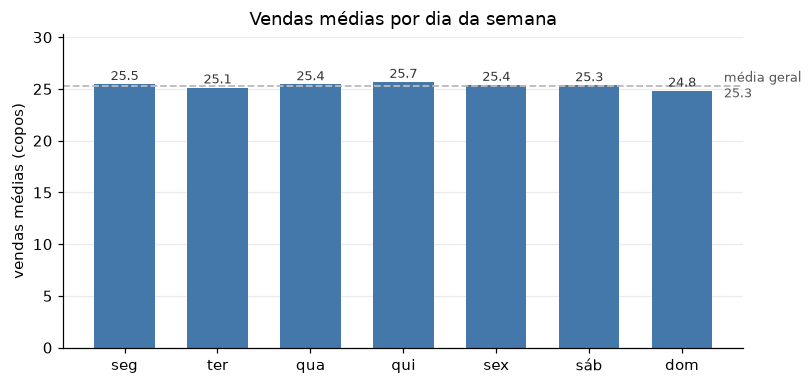

,correlação com vendas
Monday,0.008
Tuesday,-0.011
Wednesday,0.007
Thursday,0.021
Friday,0.004
Saturday,0.001
Sunday,-0.030


In [16]:
ordem_en = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
rotulos = ["seg", "ter", "qua", "qui", "sex", "sáb", "dom"]

medias = df.groupby("dia_semana")["vendas"].mean().reindex(ordem_en)
media_geral = df.vendas.mean()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
barras = ax.bar(rotulos, medias.values, color=AZUL, width=0.65)
ax.axhline(media_geral, color=CINZA, linestyle="--", linewidth=1.2)
ax.text(6.45, media_geral, f"média geral\n{media_geral:.1f}", fontsize=8.5,
        va="center", color="#555555")
for b, v in zip(barras, medias.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.4, f"{v:.1f}",
            ha="center", fontsize=8.5, color="#333333")
ax.set(ylabel="vendas médias (copos)", title="Vendas médias por dia da semana",
       ylim=(0, medias.max() * 1.18))
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

# a "correlação" de uma categórica: uma dummy por dia, correlacionada com o alvo
correl_dummies = (pd.get_dummies(df.dia_semana).astype(float)
                  .corrwith(df.vendas).reindex(ordem_en).round(3))
correl_dummies.to_frame("correlação com vendas")

**Leitura honesta: não há sinal.** As médias variam de ~24,8 a ~25,7 copos — amplitude menor que **1 copo** sobre uma média de 25 — e a correlação de cada *dummy* de dia com as vendas fica entre −0,03 e +0,02, indistinguível de zero. O eixo começando em zero conta essa história sem drama: as barras são iguais.

**Decisão:** `dia_semana` **fica fora do modelo** — atributo sem sinal só adiciona variância. Duas ressalvas de método: (a) em varejo real o dia da semana costuma importar, e muito — este dado é sintético e não carrega esse efeito; (b) a conclusão veio de **medir**, não de supor. É exatamente o gesto que faltou a quem leu o +0,51 do preço como efeito.

### Vendas ao longo do ano

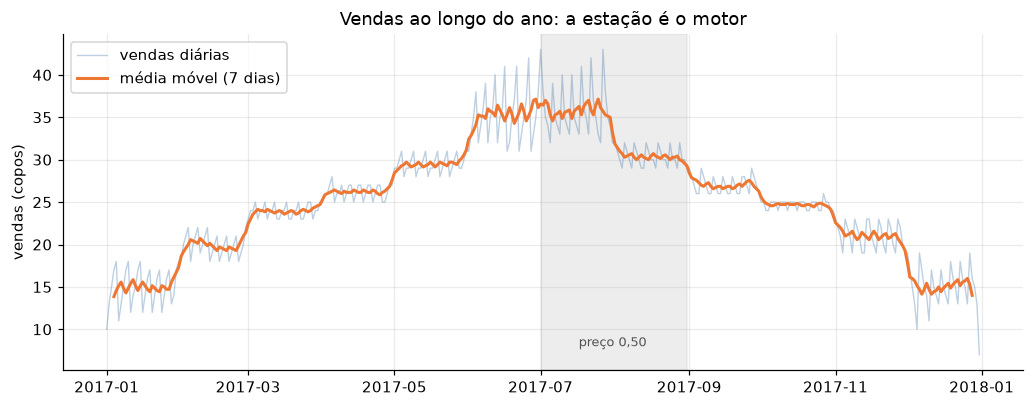

data,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31
média mensal,14.9,19.9,23.9,26.2,29.5,35.2,35.9,30.4,27.1,24.7,21.1,14.9


In [17]:
serie = df.set_index("data")["vendas"]

fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(serie.index, serie.values, color=AZUL, alpha=0.35, linewidth=0.9,
        label="vendas diárias")
ax.plot(serie.index, serie.rolling(7, center=True).mean(), color=LARANJA,
        linewidth=2, label="média móvel (7 dias)")
ax.axvspan(pd.Timestamp("2017-07-01"), pd.Timestamp("2017-08-31"),
           color=CINZA, alpha=0.25)
ax.text(pd.Timestamp("2017-07-31"), serie.min() + 1, "preço 0,50",
        ha="center", fontsize=8.5, color="#555555")
ax.set(ylabel="vendas (copos)", title="Vendas ao longo do ano: a estação é o motor")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

df.set_index("data").vendas.resample("ME").mean().round(1).to_frame("média mensal").T

A série diz em uma imagem o que a tabela do preço dizia em números: **sazonalidade forte** — média mensal de ~15 copos em janeiro e dezembro, pico de ~36 em julho — e a faixa cinza mostra o preço de 0,50 sentado **exatamente no topo do verão**. É a fotografia do confundimento: qualquer coisa que só acontece no pico "correlaciona" com vendas.

Um cuidado de método fica anotado para a próxima aula: dado com estrutura temporal aceita divisão aleatória para prever *o dia dado o tempo*, mas prever o *futuro* pediria corte por data — treinar no passado, testar no que vem depois.

## 6. Síntese da aula 1

1. **Descritiva** é forma + resumo: histograma com boxplot, assimetria, curtose — e a checagem de unidade e de tipo (a regra do IQR quebrou no `preco` binário).
2. **Outlier real não se deleta** — investiga-se; os da chuva eram o próprio fenômeno.
3. **Par a par antes do número**: a `scatter_matrix` mostra num comando a forma de todos os cruzamentos — a linearidade da temperatura, a curva da chuva, as faixas do `preco` binário, a colinearidade temperatura×panfletos.
4. **Diagnóstica**: correlação (Pearson: covariância sobre o produto dos desvios) mede associação **linear** — e o +0,51 do preço era a estação disfarçada.
5. **O calendário se mede, não se supõe**: dia da semana deu amplitude menor que 1 copo (fica fora do modelo); a série anual mostrou a sazonalidade com o preço 0,50 sentado no pico.

**Agora: a prova de 10 questões no Google Forms** — só sobre o que esta aula cobriu. 📋

> **Na próxima aula:** a regressão linear entra em campo, **item a item** — uma reta para cada variável contra `vendas`, avaliando o ajuste de cada uma (a, b, r, R², resíduos) — e depois o modelo múltiplo, Ridge/Lasso e a transformação da chuva.